In [1]:
import pandas as pd
import numpy as np

In [71]:
teen_data = pd.read_csv("Teen_Mental_Health_Dataset.csv")
teen_data
# teen_data.describe()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1195,18,female,6.8,Instagram,6.6,2.0,2.76,1.0,low,3,4,4,0
1196,16,male,2.3,Both,8.0,1.9,2.12,0.4,high,7,4,4,0
1197,14,female,1.7,Both,8.7,0.7,3.98,0.8,high,1,1,1,0
1198,15,male,3.9,Both,8.5,2.1,3.19,0.6,high,7,9,9,0


In [74]:
teen_data = pd.read_csv("Teen_Mental_Health_Dataset.csv")
teen_data
# teen_data.describe()
# teen_data['gender'] = teen_data['gender'].map({'male':0, 'female':1})
teen_data = teen_data.drop('gender', axis=1)
teen_data = teen_data.drop('platform_usage', axis=1)
teen_data = teen_data.drop('stress_level', axis=1)
teen_data = teen_data.drop('anxiety_level', axis=1)
teen_data = teen_data.drop('addiction_level', axis=1)
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
# teen_data['daily_social_media_hours'] = scaler.fit_transform(teen_data[['daily_social_media_hours']])
# teen_data['sleep_hours'] = scaler.fit_transform(teen_data[['sleep_hours']])
# teen_data['screen_time_before_sleep'] = scaler.fit_transform(teen_data[['screen_time_before_sleep']])
# teen_data['academic_performance'] = scaler.fit_transform(teen_data[['academic_performance']])
# teen_data['physical_activity'] = scaler.fit_transform(teen_data[['physical_activity']])
# teen_data['stress_level'] = scaler.fit_transform(teen_data[['stress_level']])
# teen_data['anxiety_level'] = scaler.fit_transform(teen_data[['anxiety_level']])
# teen_data['addiction_level'] = scaler.fit_transform(teen_data[['addiction_level']])
teen_data['social_interaction_level'] = teen_data['social_interaction_level'].map({"low":0, "medium":1, "high":2})
teen_data

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,depression_label
0,14,7.9,7.4,2.9,3.01,1.5,0,0
1,19,1.9,8.0,2.9,3.22,0.8,2,0
2,17,1.3,7.6,0.5,3.92,0.0,2,0
3,15,7.4,6.9,1.6,3.48,0.8,1,0
4,15,4.7,4.9,3.0,2.37,1.4,1,0
...,...,...,...,...,...,...,...,...
1195,18,6.8,6.6,2.0,2.76,1.0,0,0
1196,16,2.3,8.0,1.9,2.12,0.4,2,0
1197,14,1.7,8.7,0.7,3.98,0.8,2,0
1198,15,3.9,8.5,2.1,3.19,0.6,2,0


In [95]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

model = RandomForestClassifier()

from sklearn.model_selection import train_test_split


X = teen_data.drop("depression_label", axis=1)
y = teen_data["depression_label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.80)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

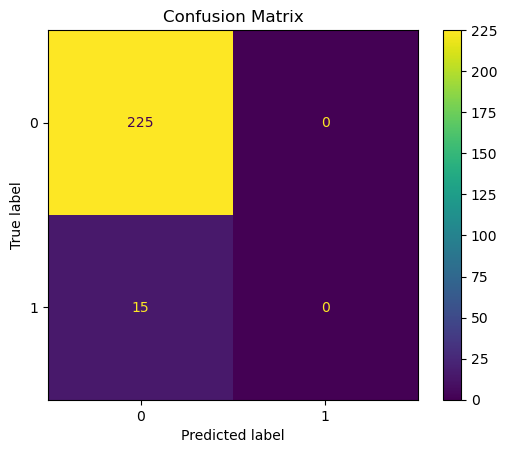

In [97]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()